# S update for Graph ALMM

## Load libraries and data

In [1]:
# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from itertools import product
from joblib import Parallel, delayed
from scipy.optimize import nnls
from sklearn.decomposition import PCA
from tabulate import tabulate

# Import functions from Chen et. al.
from graph_active_learning_functions import *

In [2]:
# Load all data and set constants

# CuSO4 (exponentially distributed)
samples = 1000
iters = 100
X_chem, S_gt_chem, A_gt_chem = load_data(name = 'synth_chem_data.npy', typename = 'chem')

# FeSO4
X_chem_FeSO4, S_gt_chem_FeSO4, A_gt_chem_FeSO4 = load_data(name = 'synth_FeSO4_data.npy', typename = 'chem')

# CuSO4
X_chem_CuSO4, S_gt_chem_CuSO4, A_gt_chem_CuSO4 = load_data(name = 'synth_CuSO4_data.npy', typename = 'chem')

# FeCl3
X_chem_FeCl3, S_gt_chem_FeCl3, A_gt_chem_FeCl3 = load_data(name = 'synth_FeCl3_data.npy', typename = 'chem')

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1000, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1000, 2)

First chemical's concentration in X (how much of class 1?):
 1.1670295769786863
<class 'numpy.ndarray'>
(1000, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1000, 1000)
Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1050, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1050, 2)

First chemical's concentration in X (how much of class 1?):
 3.180254164124069
<class 'numpy.ndarray'>
(1050, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1050, 1000)
Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1050, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1050, 2)

First chemical's concentration in X (how much of class 1?):
 1.13899

## S update

### Algorithm

In [25]:
def algo_2_graph_almm_optimized_2(X, A_0, S, alpha, beta, gamma, eta, maxIter, xi_0, L_uu, L_lu_T_A_hat_T, A_gt, A_hat, W, labeled_indices, A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "", array_plots = False):
    """
    Optimized ALMM-Based SVDL.
    Note: Requires passing A_initial (from SCLSU) as an argument since 
    SCLSU is not defined in the scope of this snippet.
    """
    p, N = X.shape
    p, q = S.shape
    q, M_0 = A_hat.shape

    L = int(p / 2)
    A_error_array = []
    RMSE_array = []
    Energy_array = []
    #A_0 = SCLSU(X, S)
    #print("Number of labeled points:", len(labeled_indices))

    # Initialize standard variables
    G = np.zeros((q, N))
    H = np.zeros((q, N))
    M = np.zeros((q, N))
    B = np.zeros((L, N))

    # 2. Track N x N diagonal matrices as 1D vectors to save O(N^2) memory
    t_diag = np.ones(N)       # Equivalent to np.eye(N)
    delta_diag = np.zeros(N)  # Equivalent to np.zeros((N, N))
    u_diag = np.zeros(N)      # Equivalent to np.zeros((N, N))

    Lambda = np.zeros((q, N)) 
    Upsilon = np.zeros((q, N)) 
    Omega = np.zeros((q, N)) 
    Theta = np.zeros((p, q))
    V = np.zeros((p, q))

    Q = np.zeros((p, L)) 
    Pi = np.zeros((p, L)) 

    A = np.copy(A_0)

    # Generate random orthogonal matrix for E
    np.random.seed(42)
    # random_matrix = np.random.randn(p, L)
    # E, _ = np.linalg.qr(random_matrix)

    # E = S - vca(X)
    Ae, _, _ = vca(X, R = q)
    diff = S - Ae


    # Pad with random columns to reach L total, then orthogonalize via QR
    pad = np.random.randn(p, L - diff.shape[1])
    E_init_raw = np.hstack([diff, pad])   # shape (p, L)

    E, _ = np.linalg.qr(E_init_raw)       # (p, L), orthonormal columns, but "seeded" by your real diff


    # Initialize scalars
    t = 0
    xi = xi_0 # originally 1e-3
    xi_max = 1e6
    rho = 1.5
    epsilon = 1e-6
    converged = False

    # Identity matrices for subproblems (sizes q, L, p only!)
    I_q = np.eye(q)
    I_L = np.eye(L)
    I_p = np.eye(p)

    # Derive unlabeled indices from labeled_indices (test)
    all_indices = np.arange(N)
    unlabeled_indices = np.setdiff1d(all_indices, labeled_indices)
    N_unlabeled = len(unlabeled_indices)  # should match L_uu.shape[0]

    while (not converged) and t < maxIter:
        

        # M subproblem (solve instead of inv)
        # S.T @ E @ B evaluated as (S.T @ E) @ B for faster multiplication
        term2_M = (S.T @ X) - (S.T @ E) @ B + (xi * (A * t_diag)) - Omega
        M_new = np.linalg.solve((S.T @ S) + xi * I_q, term2_M)

        # B subproblem
        term2_B = (E.T @ X) - (E.T @ S) @ M_new
        B_new = np.linalg.solve((E.T @ E) + beta * I_L, term2_B)

        # A subproblem
        # Multiplication by diagonal matrix T is just broadcasting: * t_diag
        term1_A = ((xi* 1) * G) + Lambda + ((xi *2)* H) + Upsilon + (Omega * t_diag) + (xi * M_new * t_diag)
        
        # term2_A was purely diagonal, so we just divide by the diagonal values!
        diag_inv = 1.0 / (xi * (t_diag ** 2) + 2 * xi)
        A_new_unproj = term1_A * diag_inv
        A_new_unproj = A_new_unproj / (A_new_unproj.sum(axis=0, keepdims=True) + 1e-10)
        A_new = project_onto_simplex(A_new_unproj) # Project onto the simplex for nonnegativity

        # S subproblem
        term1_S = M @ M.T + xi * I_q
        term2_S = (X - E @ B) @ M.T + Theta + xi * V

        S_new = np.linalg.solve(term1_S, term2_S.T).T

        # T subproblem (Woodbury Matrix Identity to avoid N x N operations)
        Y = xi * M_new + Omega
        A_At = A_new @ A_new.T
        
        # K = (I_q + A A^T)^{-1}. Since q is small (e.g. 10), this is instant.
        K = np.linalg.solve(I_q + A_At, I_q) 
        
        # Calculate exactly the diagonal components needed
        Z = Y - (K @ A_At) @ Y
        diag_At_Z = np.sum(A_new * Z, axis=0) # Fast way to get diag of A^T Z
        diag_A_K_A = np.sum(A_new * (K @ A_new), axis=0)
        
        D = xi * u_diag + delta_diag
        T_new_diag = (1.0 / xi) * diag_At_Z + (1.0 / xi) * D * (1.0 - diag_A_K_A)

        # Q subproblem
        gamma_SSt = gamma * (S_new @ S_new.T)
        term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        term2_Q = (eta * Q) + (xi * E) - Pi
        Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # E subproblem (Right-side solve using Transpose)
        term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q_new) + Pi
        term2_E_inv = (B_new @ B_new.T) + xi * I_L
        E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # G subproblem
        Z_0 = A_new - (Lambda / xi)
        G_new = half_threshold(Z_0, alpha, xi)


        # H subproblem — solve only on unlabeled portion
        I_N_unlabeled_sparse = sps.eye(N_unlabeled, format='csr')
        L_B_system = L_uu + xi * I_N_unlabeled_sparse

        # Only take unlabeled columns of A_new and Lambda for the RHS
        A_new_unlabeled = A_new[:, unlabeled_indices]      # shape (q, N_unlabeled)
        Upsilon_unlabeled = Upsilon[:, unlabeled_indices]     # shape (q, N_unlabeled)

        RHS_H = -L_lu_T_A_hat_T + xi * A_new_unlabeled.T - Upsilon_unlabeled.T  # (N_unlabeled, q)
        H_unlabeled_T = np.zeros((N_unlabeled, q))

        for j in range(q):
            H_unlabeled_T[:, j], _ = spla.cg(L_B_system, RHS_H[:, j])

        
        H_unlabeled = H_unlabeled_T.T  # (q, N_unlabeled)

        # Reassemble full-size H: labeled portion anchored to A_new, unlabeled portion from graph solve
        H_new = np.zeros((q, N))
        H_new[:, labeled_indices] = A_new[:, labeled_indices]
        H_new[:, unlabeled_indices] = H_unlabeled
        
        # U subproblem
        U_new_diag = np.maximum(0, T_new_diag - (delta_diag / xi))

        # V subproblem
        V_new = np.maximum(0, S_new - (Theta / xi))
        

        # AT subproblem 
        AT_new = A_new * T_new_diag

        # Update Lagrange multipliers
        Lambda_new = Lambda + xi * (G_new - A_new)
        Upsilon_new = Upsilon + xi * (H_new - A_new)
        Omega_new = Omega + xi * (M_new - AT_new)
        Pi_new = Pi + xi * (Q_new - E_new)
        delta_diag_new = delta_diag + xi * (U_new_diag - T_new_diag)
        Theta_new = Theta + xi * (V_new - S_new)

        xi_new = min(rho * xi, xi_max)

        # Check convergence conditions
        if ((np.linalg.norm(G_new - A_new) < epsilon) and 
            (np.linalg.norm(H_new - A_new) < epsilon) and
            (np.linalg.norm(M_new - AT_new) < epsilon) and
            (np.linalg.norm(Q_new - E_new) < epsilon) and 
            (np.linalg.norm(U_new_diag - T_new_diag) < epsilon) and
            (np.linalg.norm(E_new - E) < epsilon) and
            (np.linalg.norm(V_new - S_new) < epsilon)):

            converged = True
        else:
            t += 1

            # Calculate error
            if A_error:
                A_error_array.append(np.linalg.norm(A_new - A))
            if RMSE_plot:
                # Check for labeling issues
                corr = np.corrcoef(A[0], A_gt[0])[0, 1]
                if corr < 0:
                    A_f_corrected = 1 - A
                else:
                    A_f_corrected = A

                rmse = RMSE(A_f_corrected, A_gt)  # Calculate RMSE
                RMSE_array.append(rmse)
            if Energy_plot:
                Energy_array.append(Graph_ALMM_energy(X = X, S = S, A = A, A_hat = A_hat, 
                                                      T = t_diag, E = E, B = B, W = W, M = M_0, 
                                                      alpha = alpha, beta = beta, gamma = gamma, eta = eta, xi = xi))

            M = M_new
            B = B_new
            A = A_new
            S = S_new
            t_diag = T_new_diag
            E = E_new
            Q = Q_new
            G = G_new
            H = H_new
            u_diag = U_new_diag

            Lambda = Lambda_new
            Upsilon = Upsilon_new
            Omega = Omega_new
            Pi = Pi_new
            delta_diag = delta_diag_new
            Theta = Theta_new
            V = V_new
            xi = xi_new

    # Reconstruct the N x N diagonal matrix T at the very end to match expected output signature
    T_final = np.diag(t_diag)

    # Plot
    graph_plotter(i = t, A_error = A_error, RMSE_plot = RMSE_plot, Energy_plot = Energy_plot,
                  A_error_array = A_error_array, RMSE_array = RMSE_array, Energy_array = Energy_array, title_0 = title_0) 
    
    # Figure out what to return
    if array_plots:
        return RMSE_array, Energy_array, None, None
    else:
        return E, A, T_final, B, S

In [16]:
def run_unmixing_pipeline_example2_2(X, A_gt, S_gt, N, alpha, beta, gamma, eta, maxIter, M_total_0, m_0 = 2, xi_0 = 1e-3, OH_labels = True, print_bool = True, A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "", W_0 = None, array_plots = False):

    # ==========================================
    # Phase 1: Active Learning (Algorithm 1)
    # ==========================================

    if W_0 is None:
        if print_bool:
            print("Building initial graph for Active Learning...")
        # Scikit-learn expects (samples, features), so we pass X.T
        # K = 50 was picked for a 10000 pixel image, so roughly 0.5%
        G, W = build_custom_knn_graph(X.T, K=int(N*0.005))
    else:
        W = W_0

    if print_bool:
        print("Running Active Learning...")
    # Start with 1 random pixel per material (m=4), sample up to 0.4% of total pixels (M=40) [cite: 323]
    # num_eigs = 0.5% of the pixels (equal to K)?
    #  M_total_0 = int(0.004*N) is the default
    labeled_indices = algo_1_active_learning(X, W, m_initial=m_0, M_total=M_total_0, num_eigs=int(N*0.005))

    # ==========================================
    # Phase 2: Extract Training Data
    # ==========================================
    if print_bool:
        print("Extracting training data and generating pseudo-labels...")
    # Extract the spectral signatures for the selected pixels
    X_hat = X[:, labeled_indices]

    # Extract ground-truth abundances and convert to One-Hot pseudo-labels [cite: 321, 322] or exact labels
    A_hat_exact = A_gt[:, labeled_indices]
    L, L_ll, L_lu, L_ul, L_uu = compute_and_partition_laplacian(W, labeled_indices)

    if OH_labels:
        A_hat_OH = generate_one_hot_labels(A_hat_exact)
        L_lu_T_A_hat_T = L_lu.T @ A_hat_OH.T
        label_title = "OH"
        A_hat_test = A_hat_OH
    else:
        L_lu_T_A_hat_T = L_lu.T @ A_hat_exact.T
        label_title = "Exact"
        A_hat_test = A_hat_exact

    # ==========================================
    # Phase 3: Semi-Supervised Unmixing
    # ==========================================
    if print_bool:
        print(f"Running Graph ALMM Unmixing on {label_title}...")

    # Note: The paper mentions an overlap between X_hat and X, but updates
    # the abundance map for all pixels in X anyway.

    A_GLU, S_GLU = algo_2_glu(X, X_hat, A_hat_test, alpha, k=int(N*0.005))

    # The second condition number is a lot worse than the first
    # print("Condition number of S_gt_chem.T @ S_gt_chem:", np.linalg.cond(S_gt_chem.T @ S_gt_chem))
    # print("Condition number of S_GLU.T @ S_GLU:", np.linalg.cond(S_GLU.T @ S_GLU))

    E_final, A_final, T_final, B_final, S_final = algo_2_graph_almm_optimized_2(
        X = X, A_0 = A_GLU, S = S_GLU, alpha = alpha, 
        beta = beta, gamma = gamma, eta = eta, 
        maxIter = maxIter, xi_0 = xi_0, 
        L_uu = L_uu, L_lu_T_A_hat_T = L_lu_T_A_hat_T, A_gt = A_gt, A_hat = A_hat_test, W = W, labeled_indices = labeled_indices,
        A_error = A_error, RMSE_plot = RMSE_plot, Energy_plot = Energy_plot, title_0 = title_0, array_plots = array_plots)

    # If we just want the RMSE and/or Energy arrays
    if array_plots:
        # Slightly confusing notation, but E_final = RMSE_array and A_final = Energy_array
        return E_final, A_final, None, None

    # Calculate RMSE and SAD

    # Check for labeling issues
    corr = np.corrcoef(A_final[0], A_gt[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_final
    else:
        A_f_corrected = A_final

    A_rmse = RMSE(A_f_corrected, A_gt)
    S_sad = SAD(S_final, S_gt)

    if print_bool:
        print("Pipeline Complete!\n")
        print(f"Final Abundance Map Shape: {A_final.shape}")
        print(f"Final End-member Matrix Shape: {S_GLU.shape}")
        print(f"Final Abundance RMSE: {A_rmse}")
        print(f"Final Endmember SAD: {S_sad}")

    return A_final, S_final, A_rmse, S_sad

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on Exact...


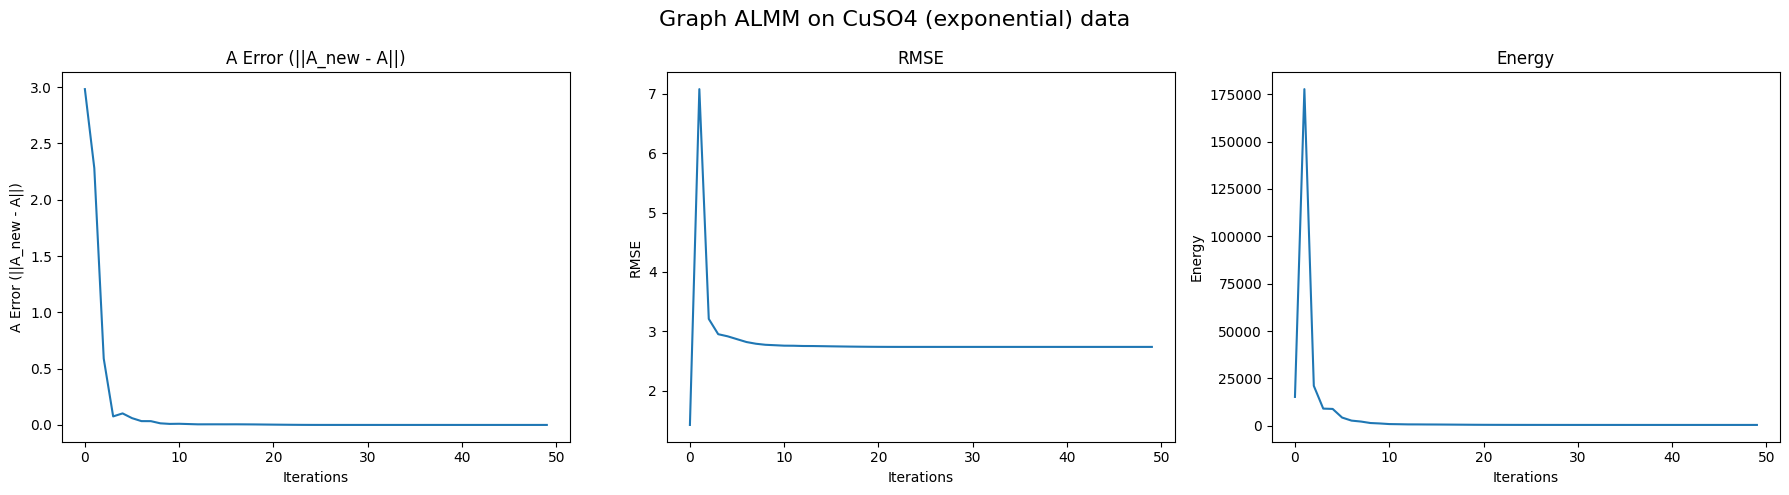

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 2.738190025291499
Final Endmember SAD: 53.55824452962573


In [26]:
# Graph ALMM
# ==========
# Best RMSE: 4.746174615631578
# Best alpha: 5.499999999999999e-07
# Best M_total: 4.0
# Best xi: 0.1
# Best label: OH

# Final Abundance Map Shape: (2, 1000)
# Final End-member Matrix Shape: (1000, 2)
# Final Abundance RMSE: 4.746175764979125
# Final Endmember SAD: 31.74438541019793

# Best RMSE + SAD: 30.267695219066475
# Best alpha: 0.0055
# Best M_total: 16.0
# Best xi: 1
# Best label: Exact

# Best RMSE: 2.7223654094235763
# Best alpha: 5.4999999999999995e-05
# Best M_total: 16.0
# Best xi: 0.01
# Best label: Exact

alpha_0 = 5.5e-5
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 1e-2
iters = 50
# Actual Run
A_graph_almm_chem, S_graph_almm_chem, A_rmse_graph_almm_chem, S_rmse_graph_almm_chem = run_unmixing_pipeline_example2_2(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 16.0, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = False, print_bool = True, 
                                                                                                                        A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on CuSO4 (exponential) data", array_plots = False)


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on Exact...


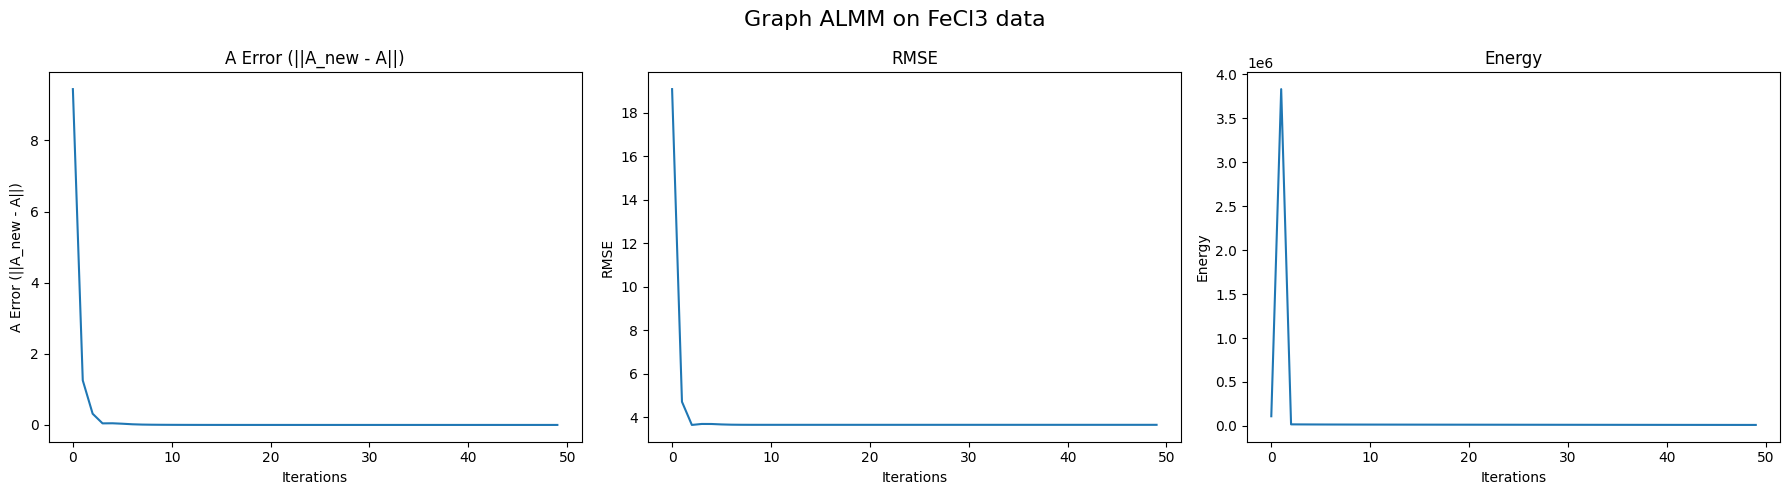

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 3.655514318434741
Final Endmember SAD: 73.41542642642897


In [27]:
# FeCl3

# Best RMSE: 3.655505130560018
# Best alpha: 5.499999999999999e-07
# Best M_total: 12.0
# Best xi: 0.001
# Best label: Exact

alpha_0 = 5.5e-7
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 1e-3
iters = 50
# Actual Run
A_graph_almm_chem, S_graph_almm_chem, A_rmse_graph_almm_chem, S_rmse_graph_almm_chem = run_unmixing_pipeline_example2_2(X = X_chem_FeCl3, A_gt = A_gt_chem_FeCl3, S_gt = S_gt_chem_FeCl3, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 12.0, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = False, print_bool = True, 
                                                                                                                        A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on FeCl3 data", array_plots = False)


### Param testing

#### RMSE + SAD

In [10]:
def min_RMSE_SAD_graph_almm(X, S, A, N, maxIter, alpha, beta, gamma, eta, M_total_0, m_0, xi_0, OH_labels, W_0 = None):
    """
    Returns the RMSE of Graph ALMM (S_sad is assumed to be constant here).
    """
    A_f, S_f, A_rmse, S_sad = run_unmixing_pipeline_example2_2(X = X, A_gt = A, S_gt = S, 
                                                             N = N, alpha = alpha, beta = beta, gamma = gamma, eta = eta, maxIter = maxIter, 
                                                             M_total_0 = M_total_0, m_0 = m_0, xi_0 = xi_0, 
                                                             OH_labels = OH_labels, print_bool = False, 
                                                             A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "", W_0 = W_0)
    
    return A_rmse + S_sad

In [ ]:
def best_param_graph_almm_RMSE_SAD(X, A_gt, S_gt, N, maxIter, alpha_0, beta_0, gamma_0, eta_0, m_0):
    """
    Performs grid search on some regularization parameters (alpha, M_total, xi, OH vs. Exact) to find
    the optimal combination of the four, minimizing the sum A_RMSE + S_SAD.

    Parameters:
    alpha_0 (numpy.ndarray): [alpha_0, alpha_0/10, alpha_0/100, alpha_0/1000, alpha_0/10000]
    M_total (numpy.ndarray): [j * (N * 0.004) for j in range(1, 5)]


    Returns:
    best (numpy.ndarray): An array with best combination minimizing A_RMSE + S_SAD
    in the format [alpha, lam, gamma, rho].
    """

    # Create a list of each combination
    alpha = [alpha_0, alpha_0/10, alpha_0/100, alpha_0/1000, alpha_0/10000]
    M_total = [j * (N * 0.004) for j in range(1, 5)]
    xi = [10**i for i in range(2, -5, -1)]
    OH_labels = [True, False]

    combos = list(product(alpha, M_total, xi, OH_labels))

    # Precompute the graph

    # ==========================================
    # Phase 1: Active Learning (Algorithm 1)
    # ==========================================
    # Scikit-learn expects (samples, features), so we pass X.T
    # K = 50 was picked for a 10000 pixel image, so roughly 0.5%
    G, W = build_custom_knn_graph(X.T, K=int(N*0.005))

    # Run the function using combinations
    results = Parallel(n_jobs =-1)(
        delayed(min_RMSE_SAD_graph_almm)(X = X, S = S_gt, A = A_gt, 
                        N = N, alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = maxIter, 
                        M_total_0 = M_total_0, m_0 = m_0, xi_0 = xi_0, 
                        OH_labels = label, W_0 = W) for alpha_0, M_total_0, xi_0, label in combos)

    # Create a 4D array to match the set order
    results = np.array(results).reshape(len(alpha), len(M_total), len(xi), len(OH_labels))

    # Find min sum value and the corresponding combination
    idx = np.unravel_index(results.argmin(), results.shape)
    min_result = results[idx]
    alpha_idx, M_total_idx, xi_idx, OH_labels_idx = idx

    # Save the best values
    alpha_best = alpha[alpha_idx]
    M_total_best = M_total[M_total_idx]
    xi_best = xi[xi_idx]
    OH_labels_best = OH_labels[OH_labels_idx]

    # changing label title for readability
    if OH_labels_best == True:
        label_title = "OH"
    else:
        label_title = "Exact"

    # Print the best values
    print(f"Best RMSE + SAD: {min_result}")
    print(f"Best alpha: {alpha_best}")
    print(f"Best M_total: {M_total_best}")
    print(f"Best xi: {xi_best}")
    print(f"Best label: {label_title}")

    return [alpha_best, M_total_best, xi_best, OH_labels_best]

In [13]:
alpha_0 = (1e-3 + 1e-2)/2
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2

best_param_graph_almm(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                      N = 1000, maxIter = 30, alpha_0 = alpha_0, beta_0 = beta_0, gamma_0 = gamma_0, eta_0 = eta_0, m_0 = 2)

Best RMSE + SAD: 30.267695219066475
Best alpha: 0.0055
Best M_total: 16.0
Best xi: 1
Best label: Exact


[0.0055, 16.0, 1, False]

#### RMSE

In [18]:
def min_RMSE_graph_almm_2(X, S, A, N, maxIter, alpha, beta, gamma, eta, M_total_0, m_0, xi_0, OH_labels, W_0 = None):
    """
    Returns the RMSE of Graph ALMM (S_sad is assumed to be constant here).
    """
    A_f, S_f, A_rmse, S_sad = run_unmixing_pipeline_example2_2(X = X, A_gt = A, S_gt = S, 
                                                             N = N, alpha = alpha, beta = beta, gamma = gamma, eta = eta, maxIter = maxIter, 
                                                             M_total_0 = M_total_0, m_0 = m_0, xi_0 = xi_0, 
                                                             OH_labels = OH_labels, print_bool = False, 
                                                             A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "", W_0 = W_0)
    
    return A_rmse

In [19]:
def best_param_graph_almm_RMSE(X, A_gt, S_gt, N, maxIter, alpha_0, beta_0, gamma_0, eta_0, m_0):
    """
    Performs grid search on some regularization parameters (alpha, M_total, xi, OH vs. Exact) to find
    the optimal combination of the four, minimizing the sum A_RMSE + S_SAD.

    Parameters:
    alpha_0 (numpy.ndarray): [alpha_0, alpha_0/10, alpha_0/100, alpha_0/1000, alpha_0/10000]
    M_total (numpy.ndarray): [j * (N * 0.004) for j in range(1, 5)]


    Returns:
    best (numpy.ndarray): An array with best combination minimizing A_RMSE + S_SAD
    in the format [alpha, lam, gamma, rho].
    """

    # Create a list of each combination
    alpha = [alpha_0, alpha_0/10, alpha_0/100, alpha_0/1000, alpha_0/10000]
    M_total = [j * (N * 0.004) for j in range(1, 5)]
    xi = [10**i for i in range(2, -5, -1)]
    OH_labels = [True, False]

    combos = list(product(alpha, M_total, xi, OH_labels))

    # Precompute the graph

    # ==========================================
    # Phase 1: Active Learning (Algorithm 1)
    # ==========================================
    # Scikit-learn expects (samples, features), so we pass X.T
    # K = 50 was picked for a 10000 pixel image, so roughly 0.5%
    G, W = build_custom_knn_graph(X.T, K=int(N*0.005))

    # Run the function using combinations
    results = Parallel(n_jobs =-1)(
        delayed(min_RMSE_graph_almm_2)(X = X, S = S_gt, A = A_gt, 
                        N = N, alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = maxIter, 
                        M_total_0 = M_total_0, m_0 = m_0, xi_0 = xi_0, 
                        OH_labels = label, W_0 = W) for alpha_0, M_total_0, xi_0, label in combos)

    # Create a 4D array to match the set order
    results = np.array(results).reshape(len(alpha), len(M_total), len(xi), len(OH_labels))

    # Find min sum value and the corresponding combination
    idx = np.unravel_index(results.argmin(), results.shape)
    min_result = results[idx]
    alpha_idx, M_total_idx, xi_idx, OH_labels_idx = idx

    # Save the best values
    alpha_best = alpha[alpha_idx]
    M_total_best = M_total[M_total_idx]
    xi_best = xi[xi_idx]
    OH_labels_best = OH_labels[OH_labels_idx]

    # changing label title for readability
    if OH_labels_best == True:
        label_title = "OH"
    else:
        label_title = "Exact"

    # Print the best values
    print(f"Best RMSE: {min_result}")
    print(f"Best alpha: {alpha_best}")
    print(f"Best M_total: {M_total_best}")
    print(f"Best xi: {xi_best}")
    print(f"Best label: {label_title}")

    return [alpha_best, M_total_best, xi_best, OH_labels_best]

In [20]:
alpha_0 = (1e-3 + 1e-2)/2
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2

best_param_graph_almm_RMSE(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                      N = 1000, maxIter = 30, alpha_0 = alpha_0, beta_0 = beta_0, gamma_0 = gamma_0, eta_0 = eta_0, m_0 = 2)

Best RMSE: 2.7223654094235763
Best alpha: 5.4999999999999995e-05
Best M_total: 16.0
Best xi: 0.01
Best label: Exact


[5.4999999999999995e-05, 16.0, 0.01, False]

In [22]:
alpha_0 = (1e-3 + 1e-2)/2
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2

best_param_graph_almm_RMSE(X = X_chem_FeCl3, A_gt = A_gt_chem_FeCl3, S_gt = S_gt_chem_FeCl3, 
                      N = 1000, maxIter = 30, alpha_0 = alpha_0, beta_0 = beta_0, gamma_0 = gamma_0, eta_0 = eta_0, m_0 = 2)

Best RMSE: 3.655505130560018
Best alpha: 5.499999999999999e-07
Best M_total: 12.0
Best xi: 0.001
Best label: Exact


[5.499999999999999e-07, 12.0, 0.001, False]